In [10]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import ast
from IPython.display import display, Markdown
import random

# Read Data

In [11]:
data_path = "../data/raw/ai_backend_dataset.jsonl"
dataset = []

with open(data_path, "r", encoding="utf-8") as f:
    for line in f:
        dataset.append(json.loads(line))

df = pd.DataFrame(dataset)
df['char_count'] = df['text'].apply(len)
df['line_count'] = df['text'].apply(lambda x: len(x.split('\n')))

print(f"Number of functions: {len(df)}")
df.head()

Number of functions: 2000


,text,char_count,line_count
0,"def _render_txt_dag_details(lines: list[str], ...",2384,45
1,"def screen_type(self, xml: str) -> str:\n ""...",647,16
2,"def on_end(self, span: ReadableSpan) -> None:\...",724,19
3,@router.get('/market/resources')\nasync def li...,2189,37
4,"def _load_model(self) -> None:\n """"""Lazy-lo...",946,16


# Distribution

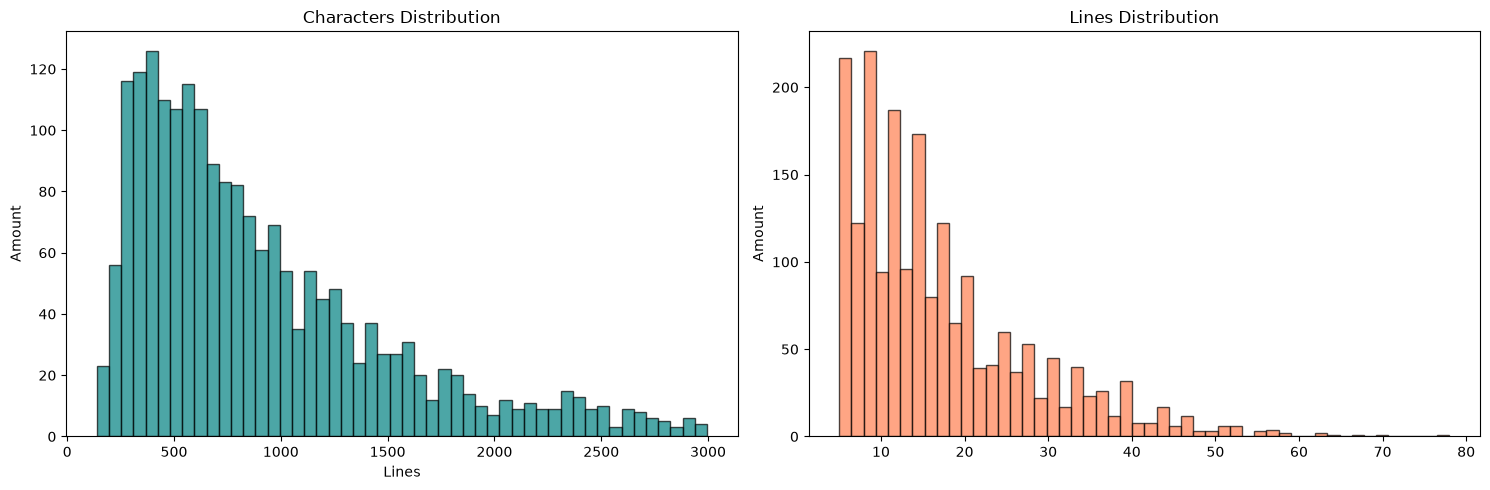

        char_count   line_count
count  2000.000000  2000.000000
mean    905.253500    17.223500
std     597.587171    10.884566
min     138.000000     5.000000
25%     455.500000     9.000000
50%     729.500000    14.000000
75%    1195.250000    22.000000
max    2995.000000    78.000000


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(df['char_count'], bins=50, color='teal', edgecolor='black', alpha=0.7)
ax1.set_title('Characters Distribution')
ax1.set_xlabel('Characters')
ax1.set_ylabel('Amount')

ax2.hist(df['line_count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax2.set_title('Lines Distribution')
ax1.set_xlabel('Lines')
ax2.set_ylabel('Amount')

plt.tight_layout()
plt.show()

print(df[['char_count', 'line_count']].describe())

# Relevancy

In [13]:
DOMAIN_KEYWORDS = {
    "async", "await", "db", "session", "query", "model", "router", "request", "response", "predict", "embed",
    
    "inference", "token", "prompt", "context", "vector", "index", "chunk", 
    "similarity", "pipeline", "tensor", "gpu", "rag", "stream",
    
    "endpoint", "middleware", "schema", "payload", "websocket", "cache", 
    "queue", "worker", "task", "batch",
    
    "crud", "orm", "transaction", "migration"
}
def audit_code_quality(code_str):
    has_type_hint = False
    try:
        tree = ast.parse(code_str)
        for node in ast.walk(tree):
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
                for arg in node.args.args:
                    if arg.annotation is not None:
                        has_type_hint = True
                        break
                if getattr(node, 'returns', None) is not None:
                    has_type_hint = True
    except SyntaxError:
        pass
    
    code_lower = code_str.lower()
    has_kw = any(kw in code_lower for kw in DOMAIN_KEYWORDS)
    return has_type_hint, has_kw

df[['has_type_hint', 'has_domain_keyword']] = df.apply(
    lambda row: pd.Series(audit_code_quality(row['text'])), axis=1
)

type_hint_ratio = df['has_type_hint'].mean() * 100
keyword_ratio = df['has_domain_keyword'].mean() * 100

print(f"Code with Type Hints: {type_hint_ratio:.2f}%")
print(f"Code with Backend/AI Keywords: {keyword_ratio:.2f}%")

Code with Type Hints: 92.60%
Code with Backend/AI Keywords: 76.90%


In [14]:
sample_size = min(3, len(df))
samples = df.sample(sample_size)['text'].tolist()

display(Markdown("## RANDOM INSPECTION RESULTS"))

for i, code in enumerate(samples, 1):
    markdown_content = f"""
#### Sample {i} (Length: {len(code)} characters)
```python
{code}
"""
display(Markdown(markdown_content))

## RANDOM INSPECTION RESULTS


#### Sample 3 (Length: 507 characters)
```python
def _relative_position_to_absolute_position(self, x):
    """
        x: [b, h, l, 2*l-1]
        ret: [b, h, l, l]
        """
    batch, heads, length, _ = x.size()
    x = F.pad(x, commons.convert_pad_shape([[0, 0], [0, 0], [0, 0], [0, 1]]))
    x_flat = x.view([batch, heads, length * 2 * length])
    x_flat = F.pad(x_flat, commons.convert_pad_shape([[0, 0], [0, 0], [0, length - 1]]))
    x_final = x_flat.view([batch, heads, length + 1, 2 * length - 1])[:, :, :length, length - 1:]
    return x_final
